# ML model tested on 2025 data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchmetrics.regression import ContinuousRankedProbabilityScore
import shap

## Load DataSets

In [3]:
# -- Train Data --
# df21 = pd.read_csv("/dmidata/users/zoerem/code/ML/training_data/filter_mu_atmo_surf_obs2345.csv") 
# df21 = pd.read_csv("/dmidata/users/zoerem/code/ML/training_data/filter_mu_atmo_surf_obs2345_promistK.csv") 
df21 = pd.read_csv("/Users/zoere/OneDrive/Bureau/cours/STAGE_M2_S10/ordi dmi/data/filter_mu_atmo_surf_obs2345_promistK.csv")

# df21

In [4]:
# --Test Data --
# DF25 = pd.read_csv("/dmidata/users/zoerem/code/ML/training_data/mashup_2025.csv")
DF25 = pd.read_csv("/Users/zoere/OneDrive/Bureau/cours/STAGE_M2_S10/ordi dmi/data/mashup_2025.csv")

# DF25

In [5]:
## temperature departure ch4_obs-sim sanity limits
maxTdep = 60.0   ## 5.0 for ch4; 6.0 for ist
minTdep = -20.550    ## -1.45 for ch4; -0.55 for ist

## Max distance between center_pixel and reference_AWS positions
max_distance_meters_pixelobs = 7
## Max difference between 2MT_nwp og 2MTDew_nwp. 0-15 K is range in data set 
max_difference_2mt_2mtdew = 15
## temperature sanity limits
maxt = 270.0 # -3°C 
mint = 200.0 # -73°C
## solar-zenith angle limits
maxsunzen = 180.0
minsunzen = 0.0
## Promice CAF upper limit
maxcaf = 1.2
## Maximum view angle
maxview = 75.0
## quality level range, ql greater than X
qlgrt = 0


## Filter data with multople conditions
df25 = DF25.loc[
    (DF25["lev1_sunzenith_angle"] >= minsunzen) & 
    (DF25["lev1_sunzenith_angle"] < maxsunzen) & 
    (DF25["lev1_satzenith_angle"] < maxview) & 
    (DF25["satcenter_station_dist_km"] < abs(max_distance_meters_pixelobs)) &     
    (DF25["lev2_quality_level"] > qlgrt) & 
    (DF25["lev2_surface_temperature"] > mint) & 
    (DF25["lev2_surface_temperature"] < maxt) & 
    (DF25["CloudCover"] < maxcaf) & 
    (DF25["nwp_t2m"]-DF25["nwp_d2m"] < max_difference_2mt_2mtdew) & 
    (DF25["SurfaceTemperature(C)"] > mint-273.15) & 
    (DF25["SurfaceTemperature(C)"] < maxt-273.15)]

df25 = df25.sort_values('lev1_obstime', ascending=True)

In [5]:
# qlv = df25["lev2_quality_level"]
# plt.hist(qlv)
# plt.show()

In [6]:
# start_dt = "2021-05-17 00:00:00"
# end_dt = "2021-06-05 23:59:59"

# # Filter data within range
# mask = (df21['lev1_obstime'] >= start_dt) & (df21['lev1_obstime'] <= end_dt)
# df21new = df21[mask]
# # df21new

## Inputs & Target

In [6]:
input_features  = [
    # "MonthOfYear", "HourOfDay(UTC)",
    "lev1_channel4", "lev1_channel5", "lev1_sunzenith_angle", "lev1_satzenith_angle",# satellites input
    "nwp_t2m", "nwp_skt", "nwp_d2m", "nwp_tcc", "nwp_u10", "nwp_v10",   "nwp_tcw", # example NWP vars
    
    # "nwp_t_1000_hPa", "nwp_t_950_hPa", "nwp_t_925_hPa",	"nwp_t_900_hPa", "nwp_t_850_hPa", "nwp_t_800_hPa", "nwp_t_700_hPa",
    # "nwp_t_600_hPa", "nwp_t_500_hPa", "nwp_t_400_hPa", "nwp_t_300_hPa", "nwp_t_250_hPa",
    # "nwp_t_200_hPa","nwp_t_150_hPa", "nwp_t_100_hPa", "nwp_t_70_hPa", "nwp_t_50_hPa", "nwp_t_30_hPa","nwp_t_20_hPa",
    # "nwp_t_10_hPa", "nwp_t_7_hPa", "nwp_t_5_hPa", "nwp_t_3_hPa", "nwp_t_2_hPa", "nwp_t_1_hPa",

    # "nwp_q_1000_hPa","nwp_q_950_hPa", "nwp_q_925_hPa",	"nwp_q_900_hPa", "nwp_q_850_hPa", "nwp_q_800_hPa", "nwp_q_700_hPa",
    # "nwp_q_600_hPa", "nwp_q_500_hPa", "nwp_q_400_hPa", "nwp_q_300_hPa", "nwp_q_250_hPa",
    # "nwp_q_200_hPa", "nwp_q_150_hPa", "nwp_q_100_hPa", "nwp_q_70_hPa", "nwp_q_50_hPa", "nwp_q_30_hPa",
    # "nwp_q_20_hPa","nwp_q_10_hPa",	"nwp_q_7_hPa", "nwp_q_5_hPa", "nwp_q_3_hPa", "nwp_q_2_hPa", "nwp_q_1_hPa",
    
]


# target_column = "SurfaceTemperature(C)"
target_column = "promistK"


## Clean: drop rows with missing data
df_clean21 = df21[input_features + [target_column]].dropna()
# df_clean21 = df21new[input_features + [target_column]].dropna()
df_clean25 = df25[input_features + [target_column]].dropna()

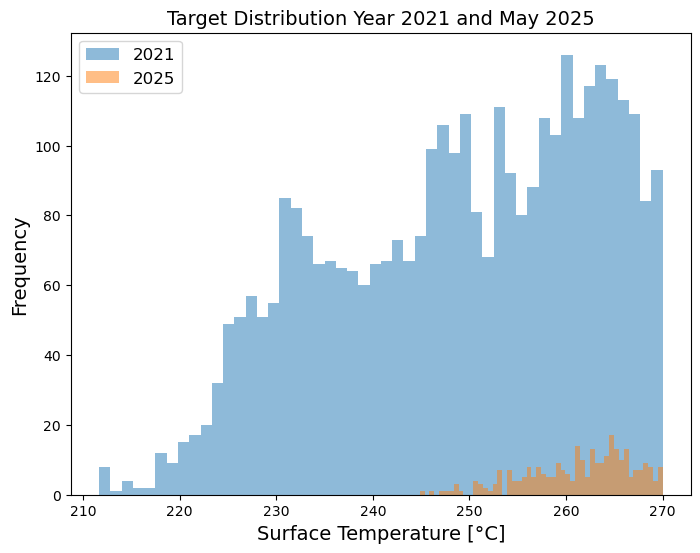

In [7]:
plt.figure(figsize=(8, 6))
plt.hist(df_clean21[target_column], bins=50, alpha=0.5, label="2021")
plt.hist(df_clean25[target_column], bins=50, alpha=0.5, label="2025")
plt.legend(fontsize = 12)
plt.title("Target Distribution Year 2021 and May 2025", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.xlabel("Surface Temperature [°C]", fontsize = 14)
# plt.savefig("/home/zoerem/Documents/STAGE/figures/distribution_ist2125.png", dpi=500, transparent=True)
plt.show()

## Split Train & Test

In [8]:
## Train/test split

X_train = df_clean21[input_features].values
X_test = df_clean25[input_features].values

y_train = df_clean21[target_column].values
y_test = df_clean25[target_column].values

## Create Datassets class

In [9]:
# PyTorch Dataset class
class ISTDataset(Dataset):
    def __init__(self, X, y): # X: the input features and y: the labels (e.g.the ground truth IST)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self): # Returns the number of samples in your dataset. Required by PyTorch to know how many batches to expect.
        return len(self.X)

    def __getitem__(self, idx): #Returns a single sample (features & target) by index.PyTorch uses this to load data batch-by-batch during training.
        return self.X[idx], self.y[idx]


## Create Dataloader (Normalized)

In [10]:
# Fit only on training data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# Apply to both
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

In [11]:
# Create datasets
train_dataset = ISTDataset(X_train_scaled, y_train)
test_dataset = ISTDataset(X_test_scaled, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Simple Regressor Model

In [12]:
# MODEL: Define a simple neural network
class SimpleRegressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [13]:
model = SimpleRegressor(len(input_features))

### Training

In [14]:
# Set up training tools
lr = 1e-3 # learning rate
loss_fn = nn.MSELoss() # mean squared error bc regression task
optimizer = torch.optim.Adam(model.parameters(), lr=lr) # using Adam, a common and effective optimization algorithm

#  Train the model
epochs = 100
epoch_losses = [] # to stock the loss and track the learning of my model
all_batch_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    num_batches = 0
    
    for X_batch, y_batch in train_loader:
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1
        all_batch_losses.append(loss.item())  # Store each batch loss

    avg_loss = running_loss / num_batches
    epoch_losses.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 49445.9375
Epoch 10 | Loss: 345.2290
Epoch 20 | Loss: 57.6177
Epoch 30 | Loss: 3.7386
Epoch 40 | Loss: 5.3661
Epoch 50 | Loss: 2.2374
Epoch 60 | Loss: 2.6946
Epoch 70 | Loss: 0.9575
Epoch 80 | Loss: 4.9282
Epoch 90 | Loss: 2.2774


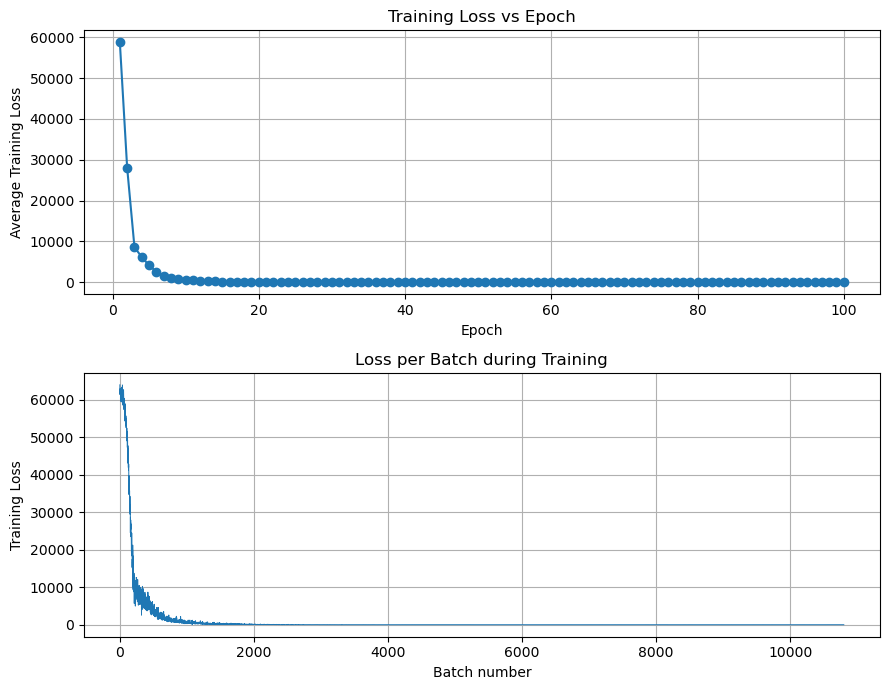

In [15]:
plt.figure(figsize=(9,7))

plt.subplot(2,1,1)
plt.plot(range(1, epochs+1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(all_batch_losses, linewidth=0.7)
plt.xlabel("Batch number")
plt.ylabel("Training Loss")
plt.title("Loss per Batch during Training")
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluation

In [16]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_pred = model(X_test_tensor).numpy()

In [17]:
# y_test and y_pred to numpy arrays
y_test_np = np.array(y_test).flatten()
y_pred_np = np.array(y_pred).flatten()

# Compute
std_residuals = np.std(y_test_np - y_pred_np)
mean_residuals = np.mean(y_test_np - y_pred_np)

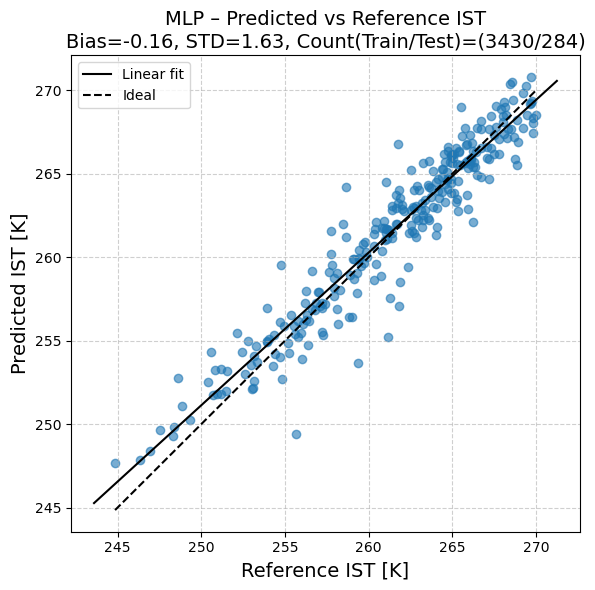

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_np, y_pred_np, alpha=0.6)

slope, intercept, r_value, p_value, std_err = linregress(y_test_np, y_pred_np)
x_vals = np.array(plt.xlim())  # take x axis limits
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="k", label="Linear fit")

plt.plot([min(y_test_np), max(y_test_np)], [min(y_test_np), max(y_test_np)], 'k--', label="Ideal")
plt.title(f"MLP – Predicted vs Reference IST\nBias={mean_residuals:.2f}, STD={std_residuals:.2f}, Count(Train/Test)=({len(train_dataset)}/{len(test_dataset)})", fontsize = 14) # \n  RMSE of {rmse:.2f} and
# plt.xlabel("Reference IST [°C]", fontsize = 14)
# plt.ylabel("Predicted IST [°C]", fontsize = 14)
plt.xlabel("Reference IST [K]", fontsize = 14)
plt.ylabel("Predicted IST [K]", fontsize = 14)
plt.legend(loc='upper left') #title="Fits",
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/2025_mlp_K.png", dpi=500, transparent=True)
plt.show()

# Shap Analysis

In [19]:
model.eval()

# Convert a small batch of background data (for SHAP's baseline)
background = torch.tensor(X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)],
                          dtype=torch.float32)

# Convert test samples to torch tensor
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Create the explainer
explainer = shap.DeepExplainer(model, background)

# Compute SHAP values for a small batch or the full test set
shap_values = explainer.shap_values(X_test_tensor)

shap_values = np.squeeze(shap_values)  # Now shape is (370, 13)

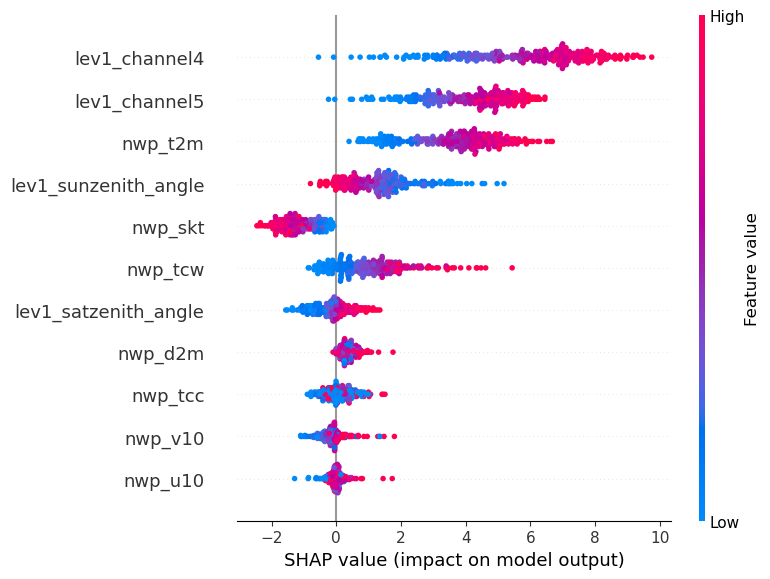

In [20]:
# If shap_values is a list (for multiple outputs), select the first
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Create the beeswarm plot

# --- Beeswarm Plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=input_features,
    plot_type="dot",   # Default: dot = beeswarm
    color_bar=True,
    show=True
)

# Probabilistic Regression Gaussian likelihood

In [21]:
class ProbabilisticRegression(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.model_var = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        mean = self.model(x)
        var = torch.exp(F.relu(self.model_var(x))+1)
        
        """
        output = self.model(x)
        mean = output[:, 0]

        # log_var = output[:, 1].clamp(min=-10.0, max=10.0)
        log_var = output[:, 1]
        var = torch.exp(log_var)
        
        # var = F.relu(output[:, 1])+1
        # var = torch.log(var)
        
        # var = output[:, 1].clamp(min=1e-6) 
        """
        
        return mean, var

### Training

In [24]:
modelvar = ProbabilisticRegression(len(input_features))
loss_gnll = nn.GaussianNLLLoss()
loss_mse = nn.MSELoss()
lr = 1e-3 
optimizer = torch.optim.Adam(modelvar.parameters(), lr=lr)
# optimizer = torch.optim.Adam(modelvar.model_var.parameters(), lr=lr)

# # optimizer Chat
# optimizer = torch.optim.Adam([
#     {'params': modelvar.model.parameters(), 'weight_decay': 1e-4},
#     {'params': modelvar.model_var.parameters(), 'weight_decay': 1e-3}
# ], lr=lr)


#  Train the model
epochs = 100

epoch_losses = []
all_batch_losses = []

for epoch in range(epochs):
    modelvar.train()
    running_loss = 0.0
    num_batches = 0
    
    for X_batch, y_batch in train_loader:
        mean, var = modelvar(X_batch)
        #print(mean)
        # loss = loss_gnll(mean, y_batch, var)
        loss_1 = loss_gnll(mean, y_batch, var)
        loss_2 = loss_mse(mean, y_batch)

        loss = loss_2 + loss_1

        # # code Maxime L1
        # lambda_l1 = 1e-4
        # l1 = 0
        # for p in modelvar.parameters():
        #         l1 = l1 + p.abs().sum()
        # loss = loss + lambda_l1 * l1

        # # code Chat L1
        # lambda_mean = 1e-4
        # lambda_var = 1e-3 
        
        # l1_mean = sum(p.abs().sum() for p in modelvar.model.parameters())
        # l1_var = sum(p.abs().sum() for p in modelvar.model_var.parameters())
        
        # loss = loss + lambda_mean * l1_mean + lambda_var * l1_var

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1
        all_batch_losses.append(loss.item())
    
    avg_loss = running_loss / num_batches
    epoch_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {avg_loss:.4f}")

Epoch 0 | Loss: 66845.5834
Epoch 10 | Loss: 620.0352
Epoch 20 | Loss: 78.4126
Epoch 30 | Loss: 23.1722
Epoch 40 | Loss: 11.2260
Epoch 50 | Loss: 7.0270
Epoch 60 | Loss: 5.3972
Epoch 70 | Loss: 4.8361
Epoch 80 | Loss: 4.4985
Epoch 90 | Loss: 4.1988


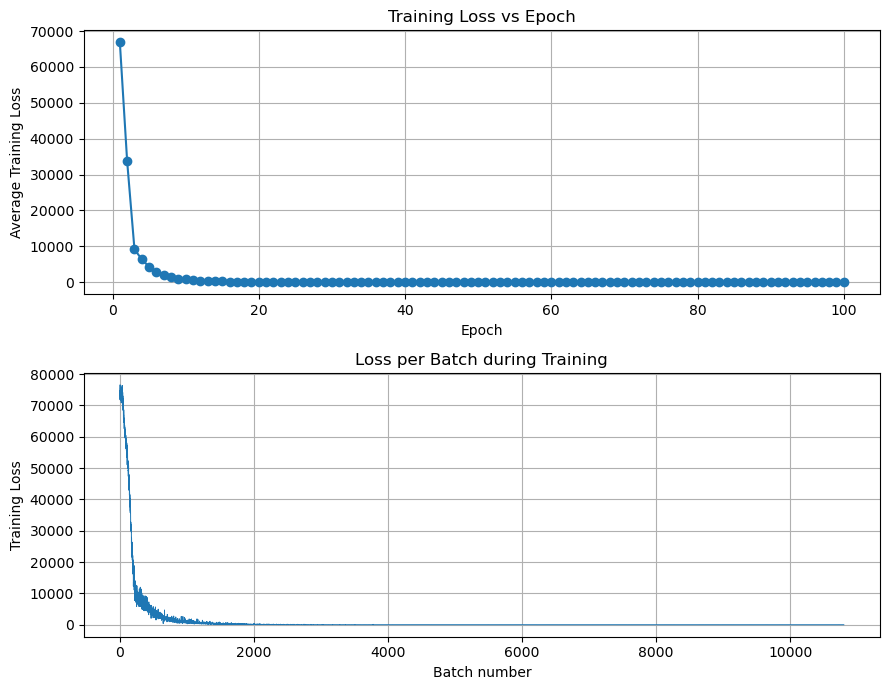

In [25]:
plt.figure(figsize=(9,7))

plt.subplot(2,1,1)
plt.plot(range(1, epochs+1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(all_batch_losses, linewidth=0.7)
plt.xlabel("Batch number")
plt.ylabel("Training Loss")
plt.title("Loss per Batch during Training")
plt.grid(True)

plt.tight_layout()
plt.show()

## Eval

In [26]:
modelvar.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    # X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    # y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
    
    mean, var = modelvar(X_test_tensor)
    # var = torch.full(var.size(),2**2) # forced GNLL

    std = torch.sqrt(var)
    means = mean.numpy().flatten()
    stds = std.numpy().flatten()
    y_test_np = y_test_tensor.numpy().flatten()
    
    # Computation of the GNLL for each points
    gnll_per_point = 0.5 * (torch.log(var) + ((mean - y_test_tensor) ** 2) / var)
    gnll_per_point = gnll_per_point.numpy().flatten()

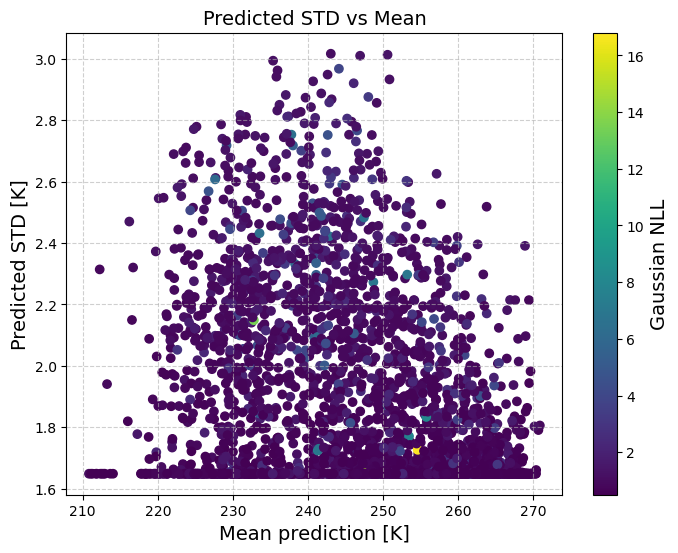

In [27]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(means, stds, c=gnll_per_point, cmap='viridis')
plt.xlabel("Mean prediction [K]", fontsize = 14)
plt.ylabel("Predicted STD [K]", fontsize = 14)
plt.title("Predicted STD vs Mean", fontsize = 14)
plt.grid(True, linestyle='--', alpha=0.6)
cbar = plt.colorbar(sc)
cbar.set_label("Gaussian NLL", fontsize = 14)
plt.show()

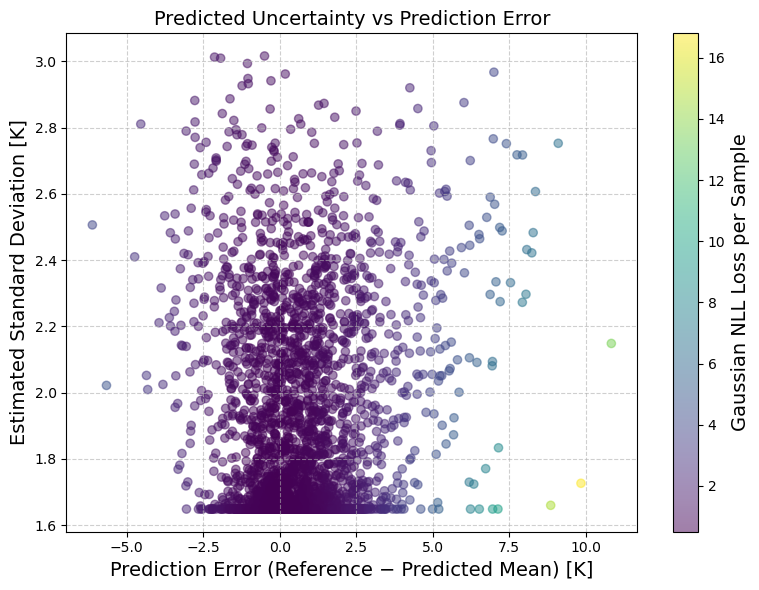

In [28]:
error_ist = y_test_np - means

plt.figure(figsize=(8, 6))

sc = plt.scatter(error_ist, stds, alpha=0.5, c=gnll_per_point, cmap='viridis')
plt.xlabel("Prediction Error (Reference − Predicted Mean) [K]", fontsize = 14)
plt.ylabel("Estimated Standard Deviation [K]", fontsize = 14)
plt.title("Predicted Uncertainty vs Prediction Error", fontsize = 14)
plt.grid(True, linestyle='--', alpha=0.6)
cbar = plt.colorbar(sc)
cbar.set_label("Gaussian NLL Loss per Sample", fontsize = 14)
plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/2025_MVE_trainingdata.png", dpi=450, transparent=True,  bbox_inches="tight")
plt.show()